# Comparison to QGIS output

I produced this geotiff output by following this blog post: [How to run visibility analysis in QGIS](https://www.helenmakesmaps.com/post/how-to-run-visibility-analysis-in-qgis). A spacing of 10 m and 20 m was tested; they returned very similar results. I am using the higher resolution 10m dataset as the test/example case to sample and compare to output from Python analysis.

The dataset below is the result of a 16 hour QGIS run, following other manual work to merge etc. the output data rasters.

Basic guidance on Rasterio plotting from [this tutorial post](https://help.marine.copernicus.eu/en/articles/5051975-how-to-open-and-visualize-geotiff-files-using-python).

In [10]:
# Imports
import rasterio
import geopandas as gpd
from rasterio.mask import mask
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load park boundaries
park_gdf = gpd.read_file("../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
print(f"Park GeoDataFrame loaded: {len(park_gdf)} features")
print(f"Park CRS: {park_gdf.crs}")
park_gdf.head()

Park GeoDataFrame loaded: 1 features
Park CRS: EPSG:4326


,Park Name,Primary Name,Park Segment Name,geometry
0,Woodhouse Moor,Woodhouse Moor,Woodhouse Moor,"POLYGON ((-1.56424 53.80949, -1.56554 53.80992..."


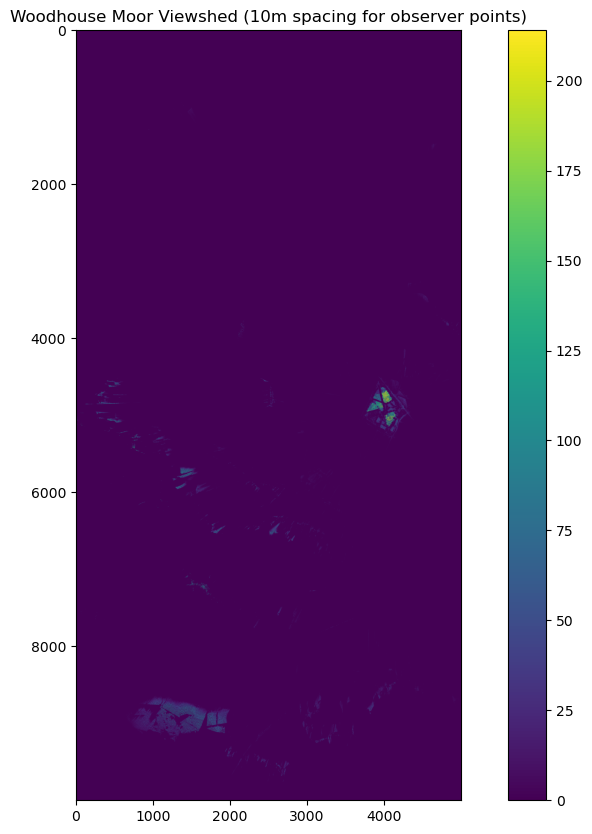

In [3]:
# Very basic plotting, to check that output dataset is as expected

# note: rasterio.plot is not included in the version of rasterio for this project

data_name = "../qgis_work/final_diff_10m.tif"
tiff = rasterio.open(data_name)

fig, ax = plt.subplots(figsize=(12, 10))
plt.imshow(tiff.read(1), cmap='viridis')
ax.set_title("Woodhouse Moor Viewshed (10m spacing for observer points)")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

In [5]:
# The TIFF is in British National Grid (LOCAL_CS defined, with bounds in BNG coordinates)
# The park is in EPSG:4326 (geographic, WGS84)
# We need to reproject the park to British National Grid (EPSG:27700)

# Reproject park to BNG (EPSG:27700)
park_gdf_bng = park_gdf.to_crs(epsg=27700)
print(f"Park reprojected to: {park_gdf_bng.crs}")
print(f"Park bounds in BNG: {park_gdf_bng.total_bounds}")

# Create a 5m buffer in the projected CRS
park_buffered_bng = park_gdf_bng.geometry.buffer(5)

# Convert to geojson format for rasterio.mask
shapes = [json.loads(gpd.GeoSeries(park_buffered_bng).to_json())['features'][0]['geometry']]

Park reprojected to: EPSG:27700
Park bounds in BNG: [428695.23831651 434725.59       429254.66       435422.8       ]


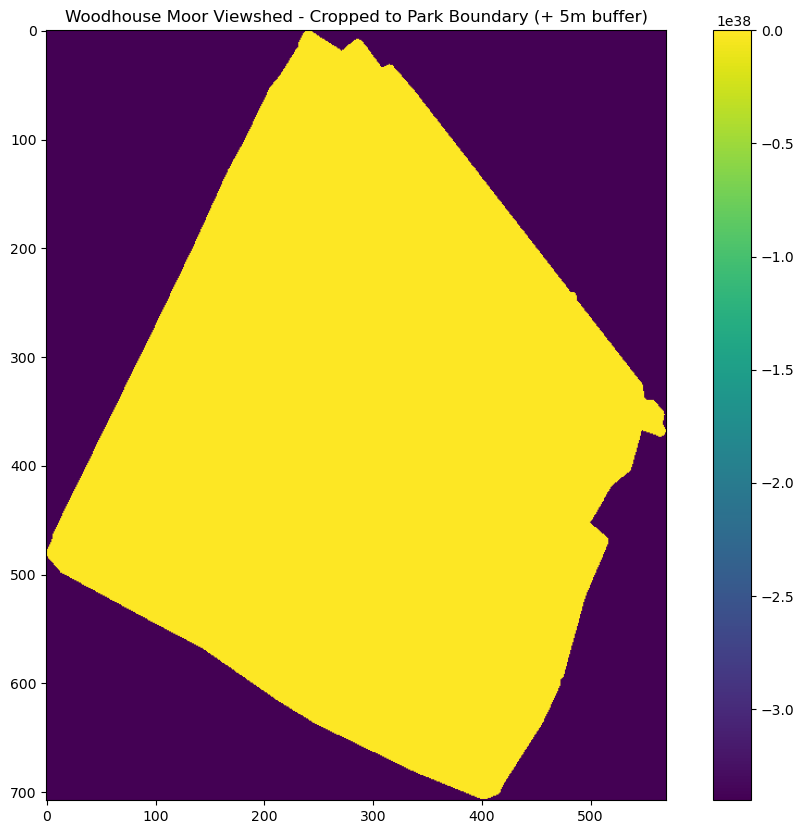

float32
-3.4028235e+38 214.0
(1, 708, 570)
[-3.4028235e+38  0.0000000e+00  1.0000000e+00  2.0000000e+00
  3.0000000e+00  4.0000000e+00  5.0000000e+00  6.0000000e+00
  7.0000000e+00  8.0000000e+00  9.0000000e+00  1.0000000e+01
  1.1000000e+01  1.2000000e+01  1.3000000e+01  1.4000000e+01
  1.5000000e+01  1.6000000e+01  1.7000000e+01  1.8000000e+01]


In [13]:
cropped_tiff, cropped_transform = mask(tiff, shapes, crop=True)
fig, ax = plt.subplots(figsize=(12, 10))
plt.imshow(cropped_tiff[0], cmap='viridis')
ax.set_title("Woodhouse Moor Viewshed - Cropped to Park Boundary (+ 5m buffer)")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

# Debug: check the data values
print(cropped_tiff.dtype)
print(cropped_tiff.min(), cropped_tiff.max())
print(cropped_tiff.shape)
print(np.unique(cropped_tiff)[:20])  # Show first 20 unique values

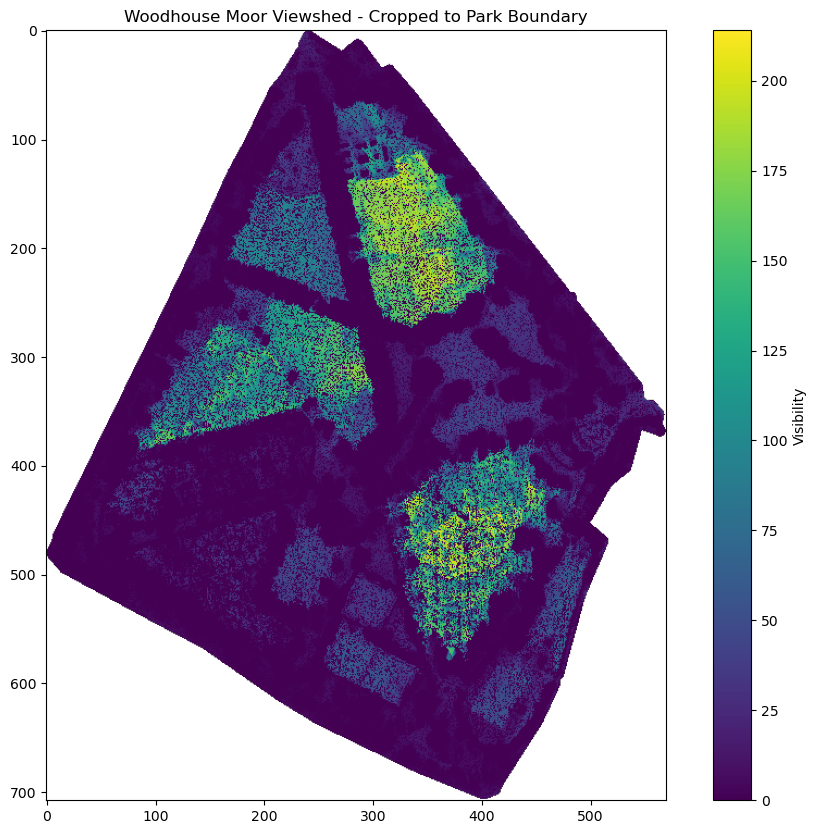

0.0 214.0


In [16]:
# Mask nodata values
# The huge negative value is the nodata value for float32
cropped_data = cropped_tiff[0].copy()
nodata_mask = cropped_data < -1e30  # Mask nodata values
cropped_data_masked = np.ma.masked_where(nodata_mask, cropped_data)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cropped_data_masked, cmap='viridis')
ax.set_title("Woodhouse Moor Viewshed - Cropped to Park Boundary")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Visibility")
plt.show()

print(cropped_data_masked.min(), cropped_data_masked.max())
